# XGBoost + SHAP


#### Methodology:
- Train one XGBoost Regressor for each target output, since all outputs—surface consumed, mid-story consumed, and canopy consumed, are continuous variables.
- Include both discrete and continuous input variables as predictors.
- Apply Label Encoding to discrete variables, as XGBoost handles label-encoded categoricals effectively.
- Use SHAP (SHapley Additive exPlanations) with the TreeExplainer to interpret feature importance for each model:
- SHAP values help identify which features contribute most to predictions.
- Use summary_plot() and dependence_plot() to visualize global and local feature impacts.
- Evaluate the model using appropriate regression metrics (e.g., RMSE, R²) and compare SHAP results across the three outputs to identify consistent drivers of fire consumption.

#### Necessary download using Anaconda Prompt (if using Anaconda)
conda install -c conda-forge xgboost shap
It will take a few minutes to download necessary libraries. 
Upon completion, it will ask Proceed y/n? Send 'yes'.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Model training
from xgboost import XGBRegressor
import shap
# Train-test split and metrics
from sklearn.model_selection import train_test_split

/opt/anaconda3/envs/enlace/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Read the CSV file
# This is the CSV file without wind height
df = pd.read_csv('df_cleaned.csv')
# View the first row to confirm it's loaded correctly
df.iloc[0]

fuel_id                       3023
unit_feature_id                 14
surface_consumed          0.352871
midstory_consumed         0.072806
canopy_consumed           0.038869
fdfm                           0.1
lfm                            0.9
wind_speed                     5.0
wind_direction               345.0
wind_height                   20.0
side_to_start_ignition       right
number_igniters                  3
firing_technique             strip
dash_length               4.571777
gap_length                4.571777
blackline_width           3.047851
spacing_distance          9.143554
igniter_velocity          0.894055
Name: 0, dtype: object

In [ ]:
# Inputs and outputs based on dataframe
inputs_list = ['fdfm','lfm','wind_speed','gap_length', 'spacing_distance', 'igniter_velocity','wind_direction'] 

outputs_list = ['surface_consumed', 'midstory_consumed', 'canopy_consumed']


In [ ]:
# Number of observations of df
print(len(df))

7886


In [5]:
# Drop rows with missing values in all input columns (no outputs)
columns_to_exclude = ['midstory_consumed', 'canopy_consumed', 'surface_consumed']

# We eliminate 'dash_length' for this analysis,'side_to_start_ignition', 'blackline_width', 'wind_height', 'firing_technique'.
df = df.drop(columns=['dash_length', 'side_to_start_ignition', 'blackline_width', 'wind_height', 'firing_technique'])

# Get all columns except outputs
columns_to_check = [col for col in df.columns if col not in columns_to_exclude]

# Drop rows that have missing values in inputs
df_cleaned = df.dropna(subset=columns_to_check)

In [6]:
# Number of observations of df
print(len(df_cleaned))

6555


In [7]:
# For appending data
models = {}
explainers = {}
shap_values_dict = {}
x_test_dict = {}  # Store x_test for each output
seed = np.random.randint(0, 10000)  # semilla aleatoria distinta cada vez

for output in outputs_list:
    df_filtered = df_cleaned.dropna(subset=[output])
    
    # Adjust inputs and outputs for excluding dropped columns
    x = df_filtered[inputs_list]
    y = df_filtered[output]

    # Number of observations of df
    print(len(df_filtered))
    
    # XGBoost
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,random_state=seed)
    model = model.fit(x_train, y_train)
    models[output] = model
    x_test_dict[output] = x_test  # Store x_test for this output

    # SHAP Method execution
    # Tree Explainer
    explainer = shap.TreeExplainer(model, x_train)
    explainers[output] = explainer

    # Shap Values Recollection
    shap_values = explainer.shap_values(x_test, check_additivity=False)
    shap_values_dict[output] = shap_values


6555
5412
5412



== SHAP Analysis for Output: surface_consumed ==
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
            feature  importance
2        wind_speed    0.054967
3        gap_length    0.049621
0              fdfm    0.048207
5  igniter_velocity    0.043671
6    wind_direction    0.028243
4  spa

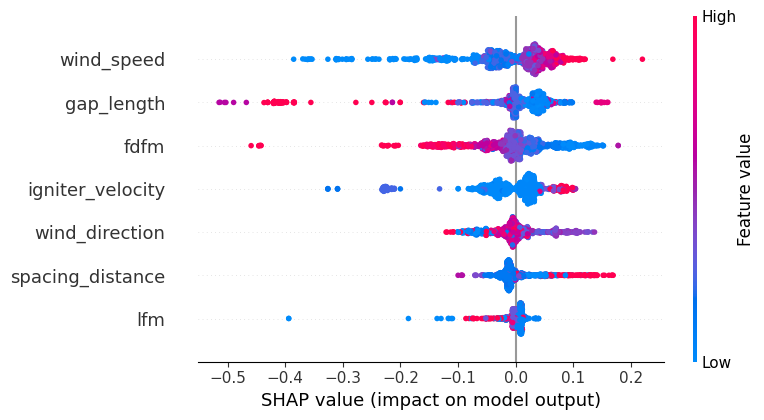


== SHAP Analysis for Output: midstory_consumed ==
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
            feature  importance
3        gap_length    0.062448
6    wind_direction    0.044756
5  igniter_velocity    0.042354
4  spacing_distance    0.033451
2        wind_speed    0.027048
0    

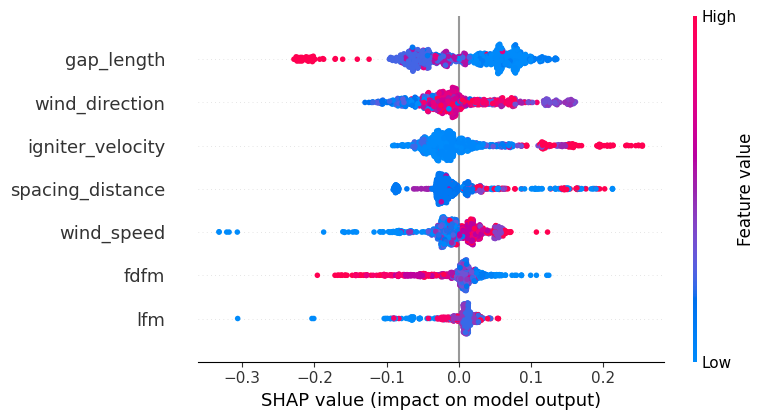


== SHAP Analysis for Output: canopy_consumed ==
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
            feature  importance
6    wind_direction    0.019579
3        gap_length    0.015432
4  spacing_distance    0.012170
2        wind_speed    0.011456
5  igniter_velocity    0.009070
1      

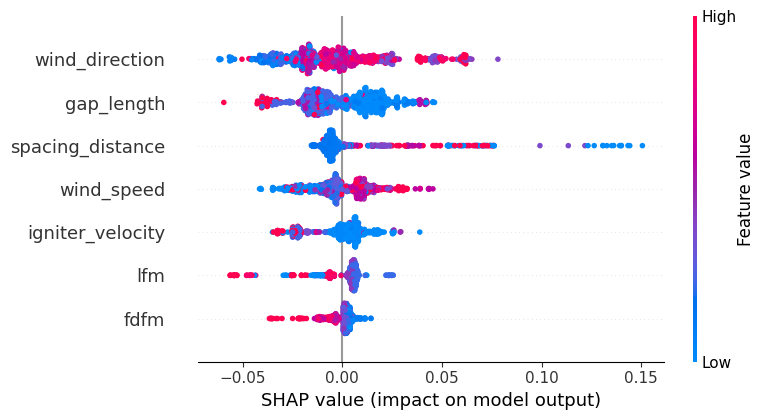

In [8]:
for output in outputs_list:
    print(f"\n== SHAP Analysis for Output: {output} ==")
    print("Model:", models[output])
    shap_values = shap_values_dict[output]
    x_test = x_test_dict[output]
    
    # Calculate absolute mean importance
    shap_abs_mean = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        "feature": x_test.columns,
        "importance": shap_abs_mean
    }).sort_values("importance", ascending=False)
    
    print(feature_importance)  # Print based onf feacture importance
    
    # Order by columns and shap_values
    ordered_features = feature_importance["feature"].tolist()
    x_test_sorted = x_test[ordered_features]
    shap_values_sorted = shap_values[:, [x_test.columns.get_loc(f) for f in ordered_features]]
    
    # Create the plot without showing it
    shap.summary_plot(shap_values_sorted, x_test_sorted, show=True)
    
    # Uncoment next two line to export as SVG with x dpi
    # x = 600
    # plt.savefig(f"shap_summary_{output}.svg", format="svg", dpi=x, bbox_inches="tight")
    plt.close()
